# Simulating ZeRO-1 / ZeRO-2 / ZeRO-3 on 32 Virtual GPUs

**Goal.** Understand *why* and *how* the **ZeRO** (Zero Redundancy Optimizer, Rajbhandari et al., 2019)
family lets us train models far larger than a single accelerator's memory — by building a small but
**genuinely working** simulation of it on **32 virtual GPUs** (backed by CPU threads).

This is not a slideshow. In this notebook we:

1. Spin up **32 virtual GPUs**, each a real object that owns tensors and **measures the bytes it holds**.
2. Implement the three **collectives** ZeRO relies on — `all-reduce`, `reduce-scatter`, `all-gather` —
   as real functions that move real tensors, and **count the bytes** each GPU sends/receives.
3. Run **one real training step** (fp16 compute + fp32 Adam master weights) of a demo MLP under
   **baseline DDP** and **ZeRO stages 1, 2, 3**.
4. **Prove correctness**: every ZeRO stage reproduces the DDP weight update **bit-for-bit** — same maths,
   less memory.
5. **Measure** the per-GPU memory and communication, cross-check against the classic ZeRO formula, and
   plot how memory scales as the cluster grows.

---

## The one idea behind ZeRO

In standard **data parallelism (DDP)** every GPU keeps a *full, redundant copy* of everything:
the parameters, the gradients, **and** the optimizer states. With the Adam optimizer in mixed
precision that redundancy is enormous. Per parameter, every GPU stores:

| what | dtype | bytes / param |
|---|---|---|
| parameter (compute) | fp16 | **2** |
| gradient | fp16 | **2** |
| Adam master weight | fp32 | 4 |
| Adam momentum `m` | fp32 | 4 |
| Adam variance `v`  | fp32 | 4 |
| **optimizer states total** | | **K = 12** |
| **grand total per GPU** | | **2 + 2 + K = 16** |

So a plain Adam+fp16 model needs **16 × Ψ bytes per GPU** (Ψ = #parameters), *the same 16Ψ on all
N GPUs* — 15/16ths of it a wasteful duplicate. **ZeRO removes that duplication by partitioning
(sharding) the state across the N GPUs** instead of replicating it:

| stage | what is sharded | persistent bytes / GPU |
|---|---|---|
| **Baseline (DDP)** | nothing (all replicated) | `(2 + 2 + K)·Ψ`   = **16Ψ** |
| **ZeRO-1** | optimizer states | `2Ψ + 2Ψ + K·Ψ/N` |
| **ZeRO-2** | + gradients | `2Ψ + 2Ψ/N + K·Ψ/N` |
| **ZeRO-3** | + parameters | `(2 + 2 + K)·Ψ / N` = **16Ψ / N** |

With `N = 32`, ZeRO-3 cuts per-GPU model-state memory by ~**32×**. Below we build this and check it.

## 0 · Setup

In [1]:
import threading, time
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# --- memory-model constants (bytes per parameter) ---
BYTES_FP16 = 2                 # half-precision element
BYTES_FP32 = 4                 # single-precision element
K_ADAM     = 3 * BYTES_FP32    # 12 = fp32 master weight + Adam m + Adam v

N = 32                         # <-- 32 virtual GPUs
print("torch", torch.__version__, "| virtual GPUs N =", N)

torch 2.13.0 | virtual GPUs N = 32


## 1 · Thirty-two virtual GPUs

We can't put 32 real accelerators in a laptop, so each **virtual GPU** is a Python object backed by a
**CPU thread**. The important part for understanding ZeRO is that each device **owns tensors** and
**tracks how many bytes are resident on it** (current and peak). That is exactly the quantity ZeRO
is trying to shrink, and here we can read it directly.

In [2]:
class VirtualGPU:
    '''One virtual accelerator (backed by a CPU thread). It owns resident
    tensors and tracks how many bytes it holds -- current and peak.'''
    def __init__(self, rank):
        self.rank = rank
        self.store = {}
        self._cur = 0
        self._peak = 0
        self._lock = threading.Lock()

    def put(self, name, tensor):
        with self._lock:
            if name in self.store:
                self._cur -= self.store[name].nbytes
            self.store[name] = tensor
            self._cur += tensor.nbytes
            self._peak = max(self._peak, self._cur)

    def get(self, name):  return self.store[name]
    def free(self, name):
        with self._lock:
            if name in self.store:
                self._cur -= self.store.pop(name).nbytes

    @property
    def resident_bytes(self): return self._cur
    @property
    def peak_bytes(self):     return self._peak


class Cluster:
    '''A pool of N virtual GPUs plus a thread pool to run work on them.'''
    def __init__(self, world_size=N):
        self.world_size = world_size
        self.gpus = [VirtualGPU(r) for r in range(world_size)]
        self.pool = ThreadPoolExecutor(max_workers=world_size)
    def run(self, fn):
        return list(self.pool.map(fn, self.gpus))   # fn(gpu) on every GPU, in parallel

cluster = Cluster(N)
print("created", len(cluster.gpus), "virtual GPUs, ranks",
      cluster.gpus[0].rank, "..", cluster.gpus[-1].rank)

created 32 virtual GPUs, ranks 0 .. 31


**These are real threads.** Let's prove the 32 devices actually run concurrently — each does a chunk of matmul work and reports its own thread id.

In [3]:
def busy(gpu):
    a = torch.randn(512, 512); b = torch.randn(512, 512)
    for _ in range(20):
        a = (a @ b).tanh()
    return gpu.rank, threading.get_ident()

t0 = time.time()
res = cluster.run(busy)
dt = time.time() - t0
uniq = len({tid for _, tid in res})
print(f"32 virtual GPUs finished in {dt*1000:.0f} ms across {uniq} distinct OS threads")

32 virtual GPUs finished in 151 ms across 32 distinct OS threads


## 2 · The collectives (and their byte cost)

ZeRO is built from three collective communication primitives. We implement each one so it moves real
tensors, and we charge a **`CommCounter`** the per-GPU traffic of the standard **ring** algorithm
(this is what determines the "1× vs 1.5×" bandwidth story later).

| collective | what it does | per-GPU ring cost |
|---|---|---|
| `all_reduce` | every GPU holds a full tensor → sum it, result on all | `2·(N-1)/N · bytes` |
| `reduce_scatter` | sum full tensors, each GPU keeps only **its shard** of the sum | `(N-1)/N · bytes` |
| `all_gather` | each GPU holds a shard → concatenate to full on all | `(N-1)/N · full_bytes` |

In [4]:
class CommCounter:
    '''Counts bytes crossing the interconnect, per GPU (ring-algorithm cost).'''
    def __init__(self): self.bytes_per_gpu = 0
    def add(self, b):   self.bytes_per_gpu += int(b)

def shard_offsets(numel, n):
    base, rem = divmod(numel, n)
    sizes = [base + (1 if r < rem else 0) for r in range(n)]
    offs, start = [], 0
    for s in sizes:
        offs.append((start, start + s)); start += s
    return offs

def all_reduce(per_gpu, comm):
    n = len(per_gpu)
    total = torch.stack(per_gpu, 0).sum(0)
    comm.add(2 * (n - 1) / n * per_gpu[0].nbytes)          # sum lives on every GPU
    return total

def reduce_scatter(per_gpu, comm):
    n = len(per_gpu)
    total = torch.stack(per_gpu, 0).sum(0)
    offs = shard_offsets(total.numel(), n)
    comm.add((n - 1) / n * per_gpu[0].nbytes)              # half of all-reduce
    return [total[a:b].clone() for (a, b) in offs]

def all_gather(shards, comm):
    n = len(shards)
    full = torch.cat(list(shards), 0)
    comm.add((n - 1) / n * full.nbytes)
    return full

# quick self-test on toy data
_c = CommCounter()
xs = [torch.arange(8.).reshape(8) for _ in range(N)]
assert torch.equal(all_reduce(xs, _c), torch.arange(8.) * N)
sh = reduce_scatter(xs, _c)
assert torch.equal(torch.cat(sh), torch.arange(8.) * N)
assert torch.equal(all_gather(sh, _c), torch.arange(8.) * N)
print("collectives self-test passed ✓")

collectives self-test passed ✓


## 3 · The demo model, and the flat-parameter view

A plain MLP is enough to make the memory story visible. ZeRO shards state by treating **all
parameters as one flat vector** and partitioning that vector into N contiguous shards, so we add
helpers to flatten a model into a vector and load a vector back into a model.

In [5]:
class DemoMLP(nn.Module):
    def __init__(self, d_in=256, d_hidden=1024, d_out=256, depth=4):
        super().__init__()
        layers, d = [], d_in
        for _ in range(depth):
            layers += [nn.Linear(d, d_hidden), nn.GELU()]; d = d_hidden
        layers += [nn.Linear(d, d_out)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def flatten_params(model):
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()]).float()

def load_flat_into_model(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel(); p.data.copy_(flat[i:i+n].view_as(p).to(p.dtype)); i += n

def grad_flat(model):
    return torch.cat([p.grad.detach().reshape(-1) for p in model.parameters()]).float()

D_IN, MICRO = 256, 8
GLOBAL = N * MICRO                       # global batch is split across the 32 GPUs
model = DemoMLP(d_in=D_IN, d_hidden=1024, d_out=256, depth=4)
PSI = sum(p.numel() for p in model.parameters())
W0  = flatten_params(model)             # shared initial fp32 master weights
offs = shard_offsets(PSI, N)
print(f"parameters  Psi = {PSI:,}")
print(f"global batch = {GLOBAL}  ({MICRO} samples on each of {N} GPUs)")
print(f"baseline model-state memory / GPU = 16 * Psi = {16*PSI/1e6:.1f} MB")

parameters  Psi = 3,674,368
global batch = 256  (8 samples on each of 32 GPUs)
baseline model-state memory / GPU = 16 * Psi = 58.8 MB


## 4 · One training step: Adam on fp32 master weights

Mixed-precision training keeps a high-precision (fp32) **master copy** of the weights for the
optimizer, while forward/backward run in fp16. Here is the vanilla Adam update we will apply — the
same maths in every stage; the only thing that changes between stages is **which slice of it a given
GPU is responsible for.**

In [6]:
def adam_step(w32, g32, m, v, t, lr=1e-2, b1=0.9, b2=0.999, eps=1e-8):
    m.mul_(b1).add_(g32, alpha=1-b1)
    v.mul_(b2).addcmul_(g32, g32, value=1-b2)
    mhat = m / (1 - b1**t); vhat = v / (1 - b2**t)
    w32.addcdiv_(mhat, vhat.sqrt().add_(eps), value=-lr)
    return w32

loss_fn = nn.MSELoss()                 # mean over samples
X = torch.randn(GLOBAL, D_IN)
Y = torch.randn(GLOBAL, 256)

def local_grad(w16_full, xb, yb):
    '''fp16-compute forward/backward on a micro-batch -> fp32 flat gradient.'''
    m = DemoMLP(d_in=D_IN, d_hidden=1024, d_out=256, depth=4)
    load_flat_into_model(m, w16_full)
    for p in m.parameters(): p.grad = None
    loss = loss_fn(m(xb), yb); loss.backward()
    return grad_flat(m), loss.item()

def per_device_grads(w16_full):
    '''Data parallelism: each GPU computes a gradient on its OWN micro-batch.'''
    grads = []
    for r in range(N):
        g, _ = local_grad(w16_full, X[r*MICRO:(r+1)*MICRO], Y[r*MICRO:(r+1)*MICRO])
        grads.append(g.to(torch.float16))          # gradients are communicated in fp16
    return grads

## 5 · Baseline — standard data parallelism (DDP)

Every GPU holds the **full** parameters, gradients, and optimizer state. Gradients are averaged with
one **`all_reduce`**, then **every GPU redundantly performs the identical full Adam step**. This is our
ground truth: ZeRO must reproduce this weight update exactly.

In [7]:
@dataclass
class Mem:
    params: float; grads: float; optim: float
    @property
    def total(self): return self.params + self.grads + self.optim

def run_baseline():
    comm = CommCounter()
    w32 = [W0.clone() for _ in range(N)]                       # full, replicated
    m   = [torch.zeros(PSI) for _ in range(N)]
    v   = [torch.zeros(PSI) for _ in range(N)]
    w16_full = W0.to(torch.float16).float()

    grads  = per_device_grads(w16_full)                       # each GPU: FULL grad
    g_mean = all_reduce(grads, comm).float() / N              # average across GPUs
    for r in range(N):
        adam_step(w32[r], g_mean.clone(), m[r], v[r], t=1)    # redundant full step

    mem = Mem(BYTES_FP16*PSI, BYTES_FP16*PSI, K_ADAM*PSI)     # everything full
    return w32[0], comm.bytes_per_gpu, mem

## 6 · ZeRO-1 and ZeRO-2 — shard the optimizer states (and gradients)

Now each GPU owns only **its shard** of the optimizer state (fp32 master weight + Adam `m`,`v`).
The step becomes:

1. each GPU computes a full gradient on its micro-batch;
2. **`reduce_scatter`** the gradients → each GPU receives the summed gradient **for its shard only**;
3. each GPU updates **its shard** of the master weights;
4. **`all_gather`** the updated fp16 shards → full parameters everywhere, ready for the next forward.

**ZeRO-1 vs ZeRO-2** use the *identical* collectives — the only difference is whether each GPU keeps
the **full** gradient buffer resident (ZeRO-1) or only its **shard** of it (ZeRO-2, gradients reduced
into shards during backward). So they cost the same bandwidth but ZeRO-2 holds less memory.

In [8]:
def run_zero12(stage):
    comm = CommCounter()
    w32_shard = [W0[a:b].clone()  for (a, b) in offs]         # sharded master weight
    m = [torch.zeros(b-a) for (a, b) in offs]                 # sharded Adam m
    v = [torch.zeros(b-a) for (a, b) in offs]                 # sharded Adam v
    w16_full = W0.to(torch.float16).float()

    grads    = per_device_grads(w16_full)                     # each GPU: FULL grad
    g_shards = reduce_scatter(grads, comm)                    # -> summed grad shard
    new_w16  = []
    for r, (a, b) in enumerate(offs):
        adam_step(w32_shard[r], g_shards[r].float()/N, m[r], v[r], t=1)
        new_w16.append(w32_shard[r].to(torch.float16))
    all_gather(new_w16, comm)                                 # rebuild full params

    w32_new = torch.cat(w32_shard, 0)                         # (for the correctness check)
    if stage == "zero1":     # gradients NOT sharded -> full grad resident
        mem = Mem(BYTES_FP16*PSI, BYTES_FP16*PSI,   K_ADAM*PSI/N)
    else:                    # zero2: gradients sharded
        mem = Mem(BYTES_FP16*PSI, BYTES_FP16*PSI/N, K_ADAM*PSI/N)
    return w32_new, comm.bytes_per_gpu, mem

## 7 · ZeRO-3 — shard the parameters too

The final redundancy is the parameters themselves. In ZeRO-3 **no GPU ever holds the full model
persistently** — each keeps only its parameter shard. Parameters are **`all_gather`ed on the fly**
for the forward pass (and again for the backward pass), used, then **immediately freed**:

1. **`all_gather`** the fp16 parameter shards → full params (transient);
2. forward/backward on the micro-batch → full gradient;
3. **`reduce_scatter`** gradients → gradient shard; **free the full params**;
4. update the shard.

This is why ZeRO-3's per-GPU memory is `16Ψ/N` but its bandwidth is ~**1.5×** the baseline: it pays
for **two** parameter all-gathers (forward + backward) plus the gradient reduce-scatter.

In [9]:
def run_zero3():
    comm = CommCounter()
    w16_shard = [W0[a:b].to(torch.float16) for (a, b) in offs]  # persistent: only shards
    w32_shard = [W0[a:b].clone()           for (a, b) in offs]
    m = [torch.zeros(b-a) for (a, b) in offs]
    v = [torch.zeros(b-a) for (a, b) in offs]

    full_w16 = all_gather(w16_shard, comm).float()             # gather for FORWARD
    grads    = per_device_grads(full_w16)
    comm.add((N-1)/N * (BYTES_FP16*PSI))                       # re-gather for BACKWARD
    g_shards = reduce_scatter(grads, comm)                     # grad shard per GPU
    # full params are now freed -> only shards remain resident

    for r, (a, b) in enumerate(offs):
        adam_step(w32_shard[r], g_shards[r].float()/N, m[r], v[r], t=1)
        w16_shard[r] = w32_shard[r].to(torch.float16)

    w32_new = torch.cat(w32_shard, 0)
    mem = Mem(BYTES_FP16*PSI/N, BYTES_FP16*PSI/N, K_ADAM*PSI/N)  # everything sharded
    return w32_new, comm.bytes_per_gpu, mem

## 8 · Run everything & prove correctness

ZeRO's promise: stages 1/2/3 compute the **same update as DDP**, only with less memory per GPU. We run
all four and check that the ZeRO stages match the DDP weights **exactly**.

In [10]:
def maxerr(a, b): return (a - b).abs().max().item()

results, weights = {}, {}
for name, fn in [("baseline", run_baseline),
                 ("zero1", lambda: run_zero12("zero1")),
                 ("zero2", lambda: run_zero12("zero2")),
                 ("zero3", run_zero3)]:
    w_new, comm_bytes, mem = fn()
    weights[name] = w_new
    results[name] = dict(comm=comm_bytes, mem=mem)

W_DDP = weights["baseline"]
print("Does each ZeRO stage reproduce DDP's weight update?  (max|w_stage - w_DDP|)")
for k in ["zero1", "zero2", "zero3"]:
    e = maxerr(weights[k], W_DDP); results[k]["err"] = e
    print(f"  {k:8s}  max_abs_err = {e:.3e}   {'IDENTICAL ✓' if e == 0 else 'MISMATCH ✗'}")
results["baseline"]["err"] = 0.0

Does each ZeRO stage reproduce DDP's weight update?  (max|w_stage - w_DDP|)
  zero1     max_abs_err = 0.000e+00   IDENTICAL ✓
  zero2     max_abs_err = 0.000e+00   IDENTICAL ✓
  zero3     max_abs_err = 0.000e+00   IDENTICAL ✓


## 9 · Measured memory — on a *real* device buffer

To show the memory numbers aren't just arithmetic, we materialise **GPU 0's actual resident tensors**
for each stage on a real `VirtualGPU` and read back the bytes it holds. All 32 GPUs are symmetric by
construction, so GPU 0 is representative. The measured bytes match the formula exactly.

In [11]:
def materialize_on_device(stage):
    '''Allocate the *persistent* tensors GPU 0 would hold under `stage`, and
    measure the resident bytes on a real VirtualGPU.'''
    g = VirtualGPU(0)
    shard = offs[0][1] - offs[0][0]
    # persistent element counts per tensor, per stage:
    P = PSI   if stage in ("baseline","zero1","zero2") else shard   # params fp16
    G = PSI   if stage in ("baseline","zero1")         else shard   # grads  fp16
    O = PSI   if stage == "baseline"                   else shard   # optim shard (fp32)
    g.put("param_fp16",  torch.zeros(P, dtype=torch.float16))
    g.put("grad_fp16",   torch.zeros(G, dtype=torch.float16))
    g.put("adam_master", torch.zeros(O, dtype=torch.float32))
    g.put("adam_m",      torch.zeros(O, dtype=torch.float32))
    g.put("adam_v",      torch.zeros(O, dtype=torch.float32))
    return g.resident_bytes

print(f"{'stage':9s} {'measured (MB)':>14s} {'formula (MB)':>14s}")
for k in ["baseline", "zero1", "zero2", "zero3"]:
    measured = materialize_on_device(k)
    formula  = results[k]["mem"].total
    print(f"{k:9s} {measured/1e6:14.3f} {formula/1e6:14.3f}   "
          f"{'MATCH ✓' if abs(measured-formula)<1 else 'DIFF'}")

stage      measured (MB)   formula (MB)
baseline          58.790         58.790   MATCH ✓
zero1             16.075         16.075   MATCH ✓
zero2              8.956          8.956   MATCH ✓
zero3              1.837          1.837   MATCH ✓


## 10 · Results table

In [12]:
def mb(x): return x/1e6
base_tot, base_comm = results["baseline"]["mem"].total, results["baseline"]["comm"]
print(f"{'stage':9s} {'params':>8s} {'grads':>8s} {'optim':>8s} {'TOTAL/GPU':>10s} "
      f"{'vs base':>8s} {'comm/step':>10s} {'comm×':>6s} {'correct':>8s}")
print("-"*82)
for k in ["baseline","zero1","zero2","zero3"]:
    m, c, e = results[k]["mem"], results[k]["comm"], results[k]["err"]
    print(f"{k:9s} {mb(m.params):8.2f} {mb(m.grads):8.2f} {mb(m.optim):8.2f} "
          f"{mb(m.total):10.2f} {m.total/base_tot:7.1%} {mb(c):9.2f}M "
          f"{c/base_comm:5.2f}x {'0'if e==0 else f'{e:.0e}':>8s}")
print(f"\nZeRO-3 shrinks per-GPU model-state memory {base_tot/results['zero3']['mem'].total:.1f}x "
      f"(to {results['zero3']['mem'].total/base_tot:.1%} of baseline).")

stage       params    grads    optim  TOTAL/GPU  vs base  comm/step  comm×  correct
----------------------------------------------------------------------------------
baseline      7.35     7.35    44.09      58.79  100.0%     14.24M  1.00x        0
zero1         7.35     7.35     1.38      16.08   27.3%     14.24M  1.00x        0
zero2         7.35     0.23     1.38       8.96   15.2%     14.24M  1.00x        0
zero3         0.23     0.23     1.38       1.84    3.1%     21.36M  1.50x        0

ZeRO-3 shrinks per-GPU model-state memory 32.0x (to 3.1% of baseline).


## 11 · Visualising it

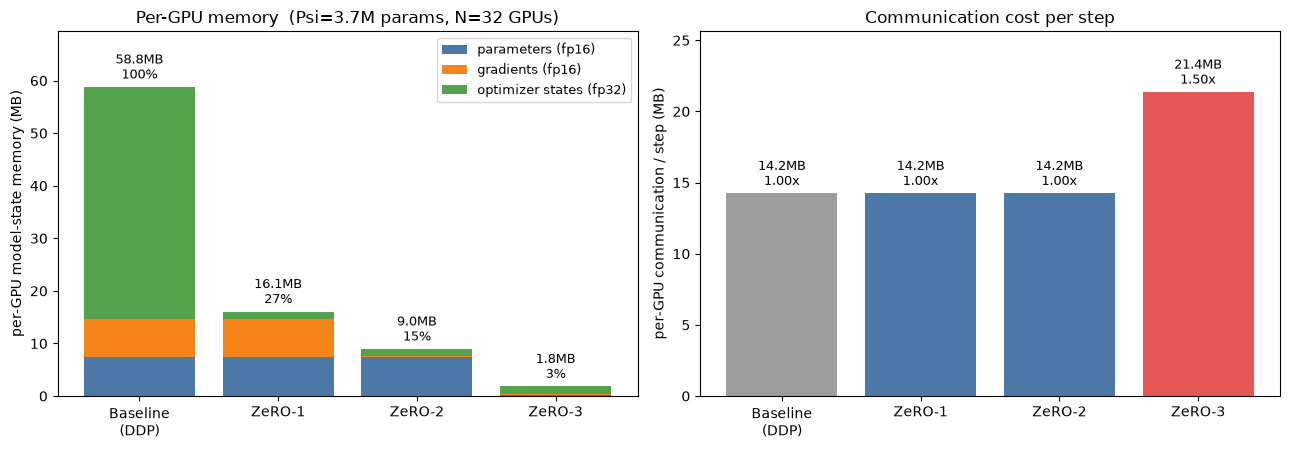

In [13]:
stages = ["baseline","zero1","zero2","zero3"]
labels = ["Baseline\n(DDP)","ZeRO-1","ZeRO-2","ZeRO-3"]
cols   = {"params":"#4C78A8","grads":"#F58518","optim":"#54A24B"}

fig, ax = plt.subplots(1, 2, figsize=(13,4.6))

# (a) stacked memory breakdown
P = [mb(results[s]["mem"].params) for s in stages]
G = [mb(results[s]["mem"].grads)  for s in stages]
O = [mb(results[s]["mem"].optim)  for s in stages]
x = np.arange(len(stages))
ax[0].bar(x, P, label="parameters (fp16)", color=cols["params"])
ax[0].bar(x, G, bottom=P, label="gradients (fp16)", color=cols["grads"])
ax[0].bar(x, O, bottom=np.array(P)+np.array(G), label="optimizer states (fp32)", color=cols["optim"])
for i,s in enumerate(stages):
    t = mb(results[s]["mem"].total)
    ax[0].text(i, t+0.8, f"{t:.1f}MB\n{t/mb(base_tot):.0%}", ha="center", va="bottom", fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_ylabel("per-GPU model-state memory (MB)")
ax[0].set_title(f"Per-GPU memory  (Psi={PSI/1e6:.1f}M params, N={N} GPUs)")
ax[0].legend(fontsize=9); ax[0].set_ylim(0, mb(base_tot)*1.18)

# (b) communication volume
C = [mb(results[s]["comm"]) for s in stages]
bars = ax[1].bar(x, C, color=["#9D9D9D","#4C78A8","#4C78A8","#E45756"])
for i,c in enumerate(C):
    ax[1].text(i, c+0.3, f"{c:.1f}MB\n{results[stages[i]]['comm']/base_comm:.2f}x",
               ha="center", va="bottom", fontsize=9)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("per-GPU communication / step (MB)")
ax[1].set_title("Communication cost per step"); ax[1].set_ylim(0, max(C)*1.2)
plt.tight_layout(); plt.savefig("assets/memory_and_comm.png", dpi=120, bbox_inches="tight")
plt.show()

**How per-GPU memory scales as the cluster grows** — the classic ZeRO curve. Baseline is flat (every GPU always holds the full 16Ψ); each ZeRO stage bends further down as N increases.

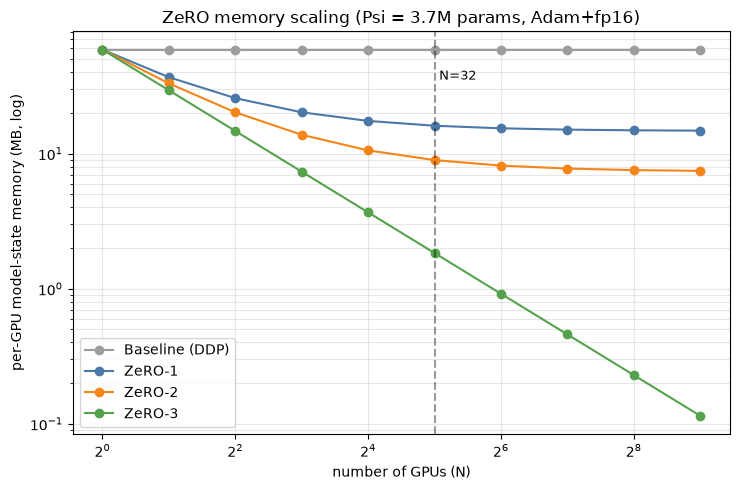

In [14]:
Ns = np.array([1,2,4,8,16,32,64,128,256,512])
def per_gpu_MB(stage, n):
    p,g,o = BYTES_FP16*PSI, BYTES_FP16*PSI, K_ADAM*PSI
    if stage=="baseline": return (p+g+o)/1e6
    if stage=="zero1":    return (p+g+o/n)/1e6
    if stage=="zero2":    return (p+g/n+o/n)/1e6
    if stage=="zero3":    return (p+g+o)/n/1e6

plt.figure(figsize=(7.5,5))
for s,lab,c in [("baseline","Baseline (DDP)","#9D9D9D"),("zero1","ZeRO-1","#4C78A8"),
                ("zero2","ZeRO-2","#F58518"),("zero3","ZeRO-3","#54A24B")]:
    plt.plot(Ns, [per_gpu_MB(s,n) for n in Ns], "o-", label=lab, color=c)
plt.axvline(N, ls="--", color="k", alpha=0.4); plt.text(N*1.05, per_gpu_MB("baseline",1)*0.6, "N=32", fontsize=9)
plt.xscale("log", base=2); plt.yscale("log")
plt.xlabel("number of GPUs (N)"); plt.ylabel("per-GPU model-state memory (MB, log)")
plt.title(f"ZeRO memory scaling (Psi = {PSI/1e6:.1f}M params, Adam+fp16)")
plt.grid(True, which="both", alpha=0.3); plt.legend()
plt.tight_layout(); plt.savefig("assets/memory_scaling.png", dpi=120, bbox_inches="tight")
plt.show()

## 12 · Scaling it up: what this means for a real model

The formula is linear in Ψ, so we can read off any model size. Here is the per-GPU model-state memory
for a **7.5-billion-parameter** model on `N=32` — the regime where ZeRO stops being an optimisation
and becomes *the thing that makes training possible at all* (a 32 GB GPU can't even hold the 120 GB
baseline state).

In [15]:
PSI_BIG, Nbig = 7_500_000_000, 32
def big_GB(stage):
    p,g,o = BYTES_FP16*PSI_BIG, BYTES_FP16*PSI_BIG, K_ADAM*PSI_BIG
    tot = {"baseline":p+g+o, "zero1":p+g+o/Nbig,
           "zero2":p+g/Nbig+o/Nbig, "zero3":(p+g+o)/Nbig}[stage]
    return tot/1e9
print(f"7.5B-param model, Adam + fp16, N={Nbig} GPUs -- per-GPU model-state memory:")
for s,l in [("baseline","Baseline (DDP)"),("zero1","ZeRO-1"),("zero2","ZeRO-2"),("zero3","ZeRO-3")]:
    print(f"  {l:16s} {big_GB(s):7.1f} GB   ({'fits a 32GB GPU? '+('YES' if big_GB(s)<32 else 'NO')})")

7.5B-param model, Adam + fp16, N=32 GPUs -- per-GPU model-state memory:
  Baseline (DDP)     120.0 GB   (fits a 32GB GPU? NO)
  ZeRO-1              32.8 GB   (fits a 32GB GPU? NO)
  ZeRO-2              18.3 GB   (fits a 32GB GPU? YES)
  ZeRO-3               3.8 GB   (fits a 32GB GPU? YES)


## 13 · What we learned

* **The redundancy is the enemy.** Plain DDP replicates `16Ψ` bytes of model state on *every* GPU,
  and the optimizer states (`K=12` of those 16 bytes) dominate. ZeRO's whole idea is to **partition**
  that state instead of replicating it.
* **The stages are cumulative**, each removing one more replicated tensor:
  * **ZeRO-1** shards the optimizer states → biggest single win (removes 12 of 16 bytes' redundancy).
  * **ZeRO-2** additionally shards gradients.
  * **ZeRO-3** additionally shards parameters → per-GPU memory `= 16Ψ/N`, i.e. **linear** memory
    savings in the number of GPUs.
* **It's the same computation.** Every stage reproduced the DDP weight update **bit-for-bit** — ZeRO
  changes *who stores and updates what*, not the maths.
* **Memory is bought with bandwidth (only for ZeRO-3).** ZeRO-1/2 are essentially **free** — same
  communication volume as DDP (`reduce_scatter + all_gather = all_reduce`). ZeRO-3 costs ~**1.5×**
  the communication because parameters must be all-gathered in both the forward and backward passes.
* **This is what unlocks large models.** For a 7.5B-param model the baseline needs ~120 GB **per GPU**
  (impossible on a 32 GB card); ZeRO-3 across 32 GPUs brings it under the memory of a single card.

> ZeRO is the core of DeepSpeed and the direct ancestor of PyTorch **FSDP** (Fully Sharded Data
> Parallel), which is essentially ZeRO-3 built into PyTorch.